In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
import tensorflow as tf

In [37]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization,Flatten,Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# paquets pour l'optimisation du cnn 

In [38]:
import splitfolders
from PIL import Image

In [39]:
from keras.preprocessing import image

In [40]:
data_dir = 'deseases/Training'
# Division des données en entrainement et validation
splitfolders.ratio(data_dir, output="dataset", seed=42, ratio=(.8, 0.2))

In [41]:
# generateur d'images

train_datagen = ImageDataGenerator(
    rescale =1./255,shear_range = 0.2,zoom_range = 0.2,horizontal_flip = True)
validation_datagen = ImageDataGenerator(rescale=1./255)

In [42]:
training_set = train_datagen.flow_from_directory('dataset/train',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')
validation_set = validation_datagen.flow_from_directory('dataset/val',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 2523 images belonging to 4 classes.
Found 633 images belonging to 4 classes.


In [43]:
# construction deep CNN
classifier = Sequential()
classifier.add(Conv2D(32, (3, 3), input_shape = (64, 64, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))
# classifier.add(Conv2D(64, (3, 3), activation = 'relu'))
# classifier.add(MaxPooling2D(pool_size = (2, 2)))
# classifier.add(Conv2D(128, (3, 3), activation = 'relu'))
# classifier.add(MaxPooling2D(pool_size = (2, 2)))
classifier.add(Flatten())
# classifier.add(Dense(units = 512, activation = 'relu'))
classifier.add(Dense(units = 128, activation = 'relu'))
classifier.add(Dense(units = 4, activation = 'softmax'))

d:\IABD-M1\IABD M1-S2\ML\Nouveau dossier\.DF_M1_S2_tf_2.16\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
classifier.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
# SGD stockastique, meme s'il ya le batch, il prendra photos par photos


In [45]:
classifier.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,936,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,937,796 (15.02 MB)

 Trainable params: 3,937,796 (15.02 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model = classifier.fit(training_set,
                         epochs=10,
                         validation_data=validation_set,
                         verbose=1)
# verbose: pour avoir les etapes de build lors de l'execution de la commandes

d:\IABD-M1\IABD M1-S2\ML\Nouveau dossier\.DF_M1_S2_tf_2.16\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.4022 - loss: 1.4371 - val_accuracy: 0.5276 - val_loss: 1.0998
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 476ms/step - accuracy: 0.5570 - loss: 1.0511 - val_accuracy: 0.6509 - val_loss: 0.8609
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 484ms/step - accuracy: 0.6523 - loss: 0.8408 - val_accuracy: 0.6761 - val_loss: 0.8166
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 481ms/step - accuracy: 0.6806 - loss: 0.7897 - val_accuracy: 0.7030 - val_loss: 0.7304
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 480ms/step - accuracy: 0.7208 - loss: 0.6967 - val_accuracy: 0.6872 - val_loss: 0.7783
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 482ms/step - accuracy: 0.7358 - loss: 0.6658 - val_accuracy: 0.7378 - val_loss: 0.7396
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 475ms/step - accuracy: 0.7472 - loss: 0.6318 - val_accuracy: 0.7409 - val_loss: 0.6672
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 469ms/step - accuracy: 0.7468 - loss: 0.6072 - val_accura

In [47]:
import sys
from PIL import Image
sys.modules['Image'] = Image

In [48]:
training_set.class_indices

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

In [49]:
y_pred = classifier.predict(validation_set)

y_pred = np.argmax(y_pred, axis=1)
y_pred

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step


array([1, 1, 0, 1, 3, 0, 3, 1, 0, 3, 3, 3, 3, 0, 3, 2, 1, 2, 1, 0, 1, 1,
       2, 0, 1, 1, 3, 3, 3, 1, 2, 2, 1, 1, 1, 2, 2, 0, 3, 2, 1, 2, 0, 1,
       3, 1, 0, 3, 2, 1, 1, 0, 1, 1, 1, 1, 3, 2, 1, 3, 0, 1, 2, 1, 0, 3,
       1, 0, 3, 1, 1, 0, 0, 3, 3, 0, 3, 2, 3, 1, 1, 2, 1, 1, 3, 2, 1, 0,
       1, 2, 1, 1, 0, 3, 1, 0, 2, 1, 3, 3, 3, 1, 3, 3, 1, 3, 3, 3, 0, 1,
       1, 1, 1, 2, 0, 1, 1, 0, 2, 3, 1, 1, 1, 3, 2, 1, 0, 3, 0, 3, 3, 1,
       0, 1, 3, 1, 1, 1, 2, 3, 1, 0, 2, 1, 2, 0, 1, 1, 3, 1, 1, 2, 2, 1,
       3, 0, 0, 2, 3, 3, 1, 0, 1, 1, 0, 3, 3, 1, 0, 1, 3, 1, 1, 0, 1, 1,
       2, 3, 0, 1, 1, 1, 3, 3, 1, 1, 0, 0, 3, 3, 1, 1, 3, 1, 2, 1, 2, 3,
       1, 0, 0, 3, 3, 3, 1, 2, 0, 0, 3, 0, 3, 2, 3, 1, 1, 2, 3, 3, 3, 1,
       3, 3, 1, 0, 3, 1, 1, 1, 2, 2, 0, 1, 1, 1, 3, 2, 3, 3, 1, 0, 1, 1,
       1, 1, 3, 1, 1, 3, 3, 2, 3, 1, 2, 1, 3, 0, 1, 0, 2, 3, 3, 1, 1, 2,
       0, 3, 1, 3, 3, 1, 2, 0, 3, 3, 1, 2, 1, 0, 1, 0, 1, 3, 1, 1, 1, 0,
       3, 3, 1, 3, 1, 3, 3, 1, 3, 2, 0, 0, 1, 0, 1,

In [50]:
from sklearn.metrics import classification_report
print(classification_report(validation_set.classes, y_pred, target_names=training_set.class_indices.keys()))

                  precision    recall  f1-score   support

    glioma_tumor       0.26      0.18      0.22       185
meningioma_tumor       0.31      0.39      0.35       188
        no_tumor       0.12      0.13      0.12        79
 pituitary_tumor       0.29      0.29      0.29       181

        accuracy                           0.27       633
       macro avg       0.24      0.25      0.24       633
    weighted avg       0.27      0.27      0.26       633



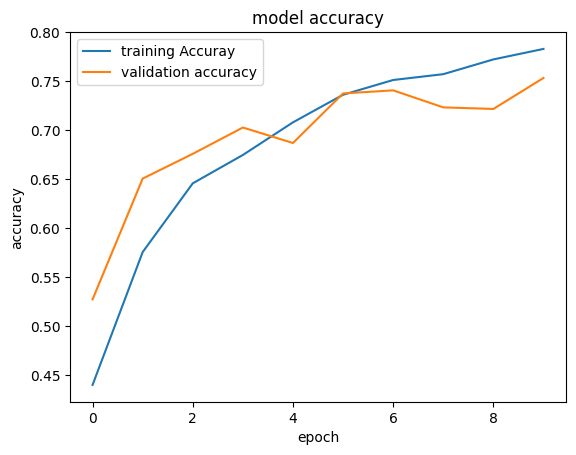

In [51]:
# evaluation du training
plt.plot(model.history['accuracy'])
plt.plot(model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training Accuray', 'validation accuracy'], loc='upper left')

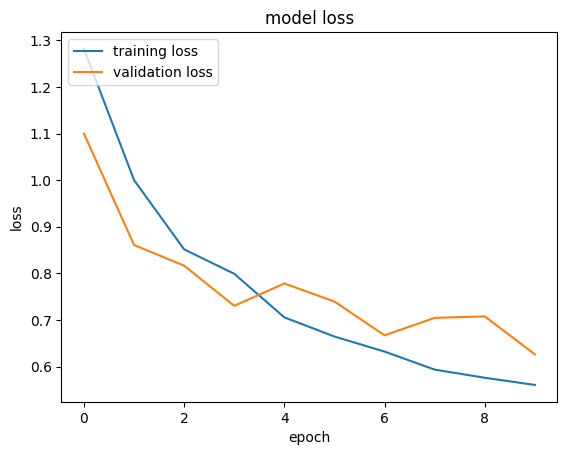

In [52]:
plt.plot(model.history['loss'])
plt.plot(model.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation loss'], loc='upper left')

In [53]:
# j veux construire le confusion matrix 
confusion_matrix = tf.math.confusion_matrix(labels=validation_set.classes, predictions=classifier.predict(validation_set).argmax(axis=1))
confusion_matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step


<tf.Tensor: shape=(4, 4), dtype=int32, numpy=
array([[36, 65, 28, 56],
       [38, 79, 19, 52],
       [15, 28, 15, 21],
       [41, 68, 24, 48]], dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

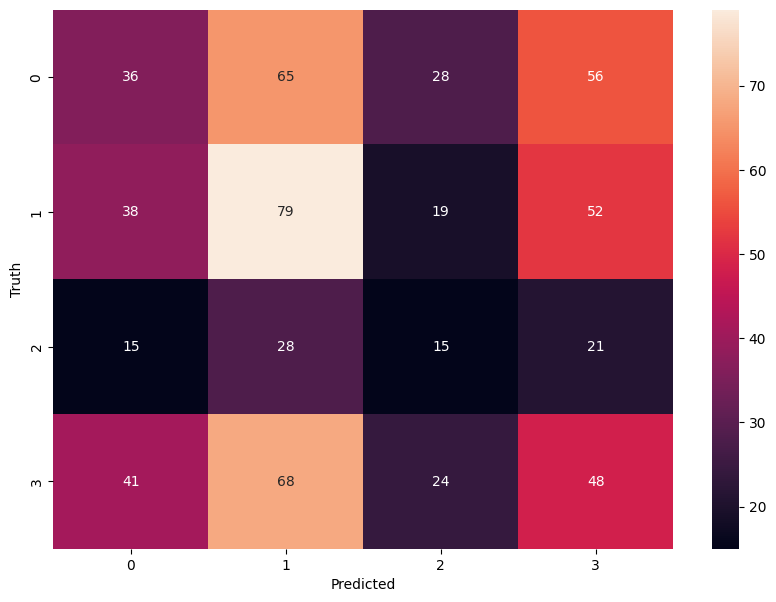

In [54]:
plt.figure(figsize = (10,7))
sns.heatmap(confusion_matrix, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [55]:
# je fais une prediction
# prediction sur une nouvelle photo
test_image = image.load_img('test_images/gioma.jpg', target_size = (64, 64))
test_image = image.img_to_array(test_image) # je transforme l'image en array
test_image = np.expand_dims(test_image, axis = 0) # j'ajoute une dimension avec expand_dims
result = classifier.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


In [56]:
result

array([[0., 1., 0., 0.]], dtype=float32)

In [57]:
# j'identifie la classe prédite
predicted_class_index = np.argmax(result)

In [58]:
# je fais les correspondance avec les noms des classes
class_indices = training_set.class_indices
# Inverser le dictionnaire pour aller de l'indice vers le nom de la classe
labels = {v: k for k, v in class_indices.items()}

# Récupérer le label prédict
predicted_class_label = labels[predicted_class_index]
print("Classe prédite :", predicted_class_label)

Classe prédite : meningioma_tumor
